In [27]:
import math
import numpy as np
from matplotlib import pyplot as plt
from scipy import linalg as sln
from scipy import sparse


We move on to 2D, solving heat conduction on a plate. 

Governing equation: $\frac{\partial u}{\partial t} = \kappa(\frac{\partial^2 u}{\partial x^2}+\frac{\partial^2 u}{\partial y^2})$

Using uniform mesh sizes $h$ in a Cartesian grid, we first proceed with a uniform rectangular domain with length $L$ and height $H$.

Denote index $i, j$ subscript for steps in space, $\delta$ superscript for steps in time.

$\frac{\partial u}{\partial t} \approx \frac{1}{\Delta t}(u_{i,j} ^{(\delta + 1)}- u_{i,j} ^{(\delta)})$ is the forward difference in time.

$\frac{\partial^2 u}{\partial x^2} \approx \frac{1}{h^2}(u_{i+1,j} ^{(\delta)} + u_{i-1,j} ^{(\delta)} + u_{i,j+1} ^{(\delta)} + u_{i,j-1} ^{(\delta)} - 4u_{i,j} ^{(\delta)})$ 

If our mesh is anisotropic, i.e. the mesh size in x and y differ, then the difference equation must be: 

$\kappa\frac{\partial^2 u}{\partial x^2} \approx \frac{\kappa}{\Delta x^2}(u_{i+1,j} ^{(\delta)} + u_{i-1,j} ^{(\delta)} - 2u_{i,j} ^{(\delta)}) + \frac{\kappa}{\Delta y^2}(u_{i,j+1} ^{(\delta)} + u_{i,j-1} ^{(\delta)} - 2u_{i,j} ^{(\delta)})$ 

is the second order central difference in x and y, using a five-point stencil.

In [28]:
kappa = 0.5

In [76]:
def heatequation2D(time_span, u0, dt, points_interior, dims, b):
    t_init, t_end = time_span
    px, py = points_interior
    Lx, Ly = dims
    hx, hy = (Lx/(px+1),Ly/(py+1))

    interior = px*py
    
    t = np.arange(t_init, t_end + dt, dt)
    interval = len(t)

    u0 = np.atleast_1d(u0).astype(float)

    u = np.zeros((interior,interval), dtype = float)
    u[:,0] = u0

    b = b.astype(float)
    
    #Define the 1D Laplacian in x and y
    Kx = sparse.diags([1,-2,1], [-1,0,1], shape = (px,px))
    Ky = sparse.diags([1,-2,1], [-1,0,1], shape = (py,py))

    Ix = sparse.identity(px)
    Iy = sparse.identity(py)

    #Define the 2D discrete Laplacian using the Kronecker product:
    IyKx = sparse.kron(Iy, Kx) 
    KyIx = sparse.kron(Ky, Ix)

    L = IyKx + KyIx

    I = sparse.identity(interior)

    rx, ry = (kappa * dt / hx**2, kappa * dt / hy**2)

    #Applying the Crank-Nicolson scheme.

    B =  I - 0.5*(rx*IyKx + ry*KyIx)
    B = B.tocsc()
    A =   I + 0.5*(rx*IyKx + ry*KyIx)
    A = A.tocsc()

    solver = sparse.linalg.splu(B.tocsc())

    for i in range(interval - 1):
        rhs = A @ u[:,i] + dt*b 
        u[:,i+1] = solver.solve(rhs)
        

    return t, u

In [ ]:
def heatequation2D_nohistory(time_span, u0, dt, points_interior, dims, b):
    t_init, t_end = time_span
    px, py = points_interior
    Lx, Ly = dims
    hx, hy = (Lx/(px+1),Ly/(py+1))

    interior = px*py
    
    t = np.arange(t_init, t_end + dt, dt)
    interval = len(t)

    u0 = np.atleast_1d(u0).astype(float)

    u = u0.copy().astype(np.float32)

    u[:,0] = u0

    b = b.astype(float)
    
    #Define the 1D Laplacian in x and y
    Kx = sparse.diags([1,-2,1], [-1,0,1], shape = (px,px))
    Ky = sparse.diags([1,-2,1], [-1,0,1], shape = (py,py))

    Ix = sparse.identity(px)
    Iy = sparse.identity(py)

    #Define the 2D discrete Laplacian using the Kronecker product:
    IyKx = sparse.kron(Iy, Kx) 
    KyIx = sparse.kron(Ky, Ix)

    L = IyKx + KyIx

    I = sparse.identity(interior)

    rx, ry = (kappa * dt / hx**2, kappa * dt / hy**2)

    #Applying the Crank-Nicolson scheme.

    B =  I - 0.5*(rx*IyKx + ry*KyIx)
    B = B.tocsc()
    A =   I + 0.5*(rx*IyKx + ry*KyIx)
    A = A.tocsc()

    solver = sparse.linalg.splu(B.tocsc())

    for i in range(interval - 1):
        rhs = A.dot(u) + dt*b 
        u = solver.solve(rhs)
        
    return t, u

In [77]:
#Boundary conditions

#construct the boundary/forcing vector b from four walls

def boundary_dirichlet(
        points_interior, dims, T_edges):
    #if input not right size, error
    px,py = points_interior
    Lx,Ly = dims
    hx,hy = (Lx/(px+1),Ly/(py+1))
    interior = px*py
    T_left, T_right, T_bottom, T_top = T_edges
    
    b = np.zeros(interior)

    for j in range(py):
        for i in range(px):

            k = i + j*px

            if i == 0:
                b[k] += T_left / hx**2
            if i == px-1:
                b[k] += T_right / hx**2
            if j == 0:
                b[k] += T_bottom / hy**2
            if j == py-1:
                b[k] += T_top / hy**2
    return b


In [78]:
#Define grid
px,py = (199, 199)
size = (20, 20)

#Define initial conditions
u0_2d = np.zeros((px,py)) #initiate

    #ring of points initial conditions:
u0_2d[px//2, py//2] = 100
# u0_2d[pxpy[0]//4, pxpy[1]//4] = 5
# u0_2d[3*pxpy[0]//4, 3*pxpy[1]//4] = 5
# u0_2d[pxpy[0]//4, 3*pxpy[1]//4] = 5
# u0_2d[3*pxpy[0]//4, pxpy[1]//4] = 5
# u0_2d[100, 25] = 5
# u0_2d[25, 100] = 5
# u0_2d[100, 175] = 5
# u0_2d[175, 100] = 5

#The initial condition must be flat to input into the function.
u0_flat = u0_2d.ravel()


b0 = boundary_dirichlet((px,py), size, (0,0,0,0))
b1 = boundary_dirichlet((px,py), size, (1,1,1,1))

In [79]:
time, sol_flat = heatequation2D((0,10), u0_flat, 0.01, (px,py), size, b = b1)
print(time.shape, sol_flat.shape)

(1001,) (39601, 1001)


In [ ]:
time, sol_flat = heatequation2D((0,10), u0_flat, 0.01, (px,py), size, b = b1)
print(time.shape, sol_flat.shape)

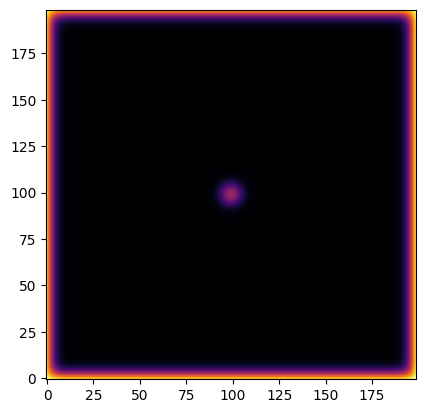

In [80]:
#indeed, any representation of the grid point values are all flattened 
#before being computed on, and must be restored for plotting.
sol_2d = sol_flat[:, 20].reshape((px,py))
plt.clf()
plt.imshow(sol_2d, origin='lower', cmap = 'inferno')
